In [13]:
from network_module import WeightedNetwork, AbstractNode, Message, visualize_graph
import networkx as nx
from enum import Enum
from typing import Tuple, List
import logging

In [14]:
class MessageType(Enum):
    FIND_MWOE = "find_mwoe"
    REPLY_MWOE = "reply_mwoe"
    CHECK = "check"
    CHECK_RESPONSE = "check_response"
    BROADCAST_MWOE = "broadcast_mwoe"
    REQUEST_TO_MERGE = "request_to_merge"
    REJECT_MERGE_REQUEST = "accept_merge_request"
    NEW_FRAGMENT = "new_fragment"


class NodeState(Enum):
    SEARCH = "search"  # broadcasting find MWOE messages in the fragment
    FIND_MWOE = "find_mwoe"  # finding that nodes MWOE by checking with neighbours
    WAIT_FOR_RESPONSE = "wait_for_response"  # convergecast, waiting to forward onto parent MOE of the subtree of the fragment
    BROADCAST_MOE = "broadcast_moe"
    MERGE = (
        "merge"  # sent the convergecast message and ready to move onto the next phase
    )
    WAITING = "waiting"


class EdgeState(Enum):
    BASIC = "basic"
    BRANCH = "branch"
    REJECTED = "rejected"

In [15]:
logging.basicConfig(
    filename="ghs_node_log.txt",
    level=logging.INFO,
    format="%(asctime)s - %(message)s"
)

In [16]:
class GHSNode(AbstractNode):
    def __init__(self, node_id, neighbours):
        super().__init__(node_id, neighbours)
        self.state: NodeState = NodeState.SEARCH
        self.fragment_id: int = self.node_id
        self.leader_id: int = self.node_id
        self.expected_replies: int = 0
        self.parent: int = None
        self.mwoe_candidate: int = None
        self.mwoe: Tuple[int, float] = None
        self.mwoe_candidates: List[int] = []
        self.fragment_mwoe_weight: int = None
        self.merge_candidate: int = (
            None  # this takes the value of the node adjacent to the MWOE of the fragment only if this node is adjacent to the MWOE otherwise it remains none. Will need to clean up however (i.e. old values not good)
        )
        self.merge_requests: List[Message] = []

        self.adjacent_edges = {
            neighbor: {"status": EdgeState.BASIC, "weight": weight}
            for neighbor, weight in self._neighbours.items()
        }

        self.merge_fragment_id: List[int] = (
            None  # the id of the old fragments this nodes fragment is merging, this is used to make sure CHECK message work as new fragment messages can take time to propagate
        )

    def send_message(self, recipient, content):
        """
        Send a message to a recipient and log the message.
        """
        # Log the message being sent
        logging.info(f"Node {self.node_id} sent message to Node {recipient}: {content}")
        # Call the parent class's send_message method (assuming it exists)
        super().send_message(recipient, content)

    def _find_mwoe_candidate(self):
        min_weight = float("inf")
        min_neighbour = None

        for neighbour, edge in self.adjacent_edges.items():
            if edge["status"] == EdgeState.BASIC and edge["weight"] < min_weight:
                min_weight = edge["weight"]
                min_neighbour = neighbour

        if min_neighbour is not None:
            # check the minimum weight adjacent edge leaves the fragment
            self.send_message(
                min_neighbour,
                {
                    "request": MessageType.CHECK,
                    "id": self.node_id,
                    "fragment_id": self.fragment_id,
                },
            )

            self.mwoe_candidate = min_neighbour
        else:
            # No candidate edges, set mwoe to None
            self.mwoe = (None, None)
            self.state = NodeState.WAIT_FOR_RESPONSE

    def _flood_new_fragment(self, message: Message) -> None:
        # print(
        #     f"I node {self.node_id} am flooding, here are my adjacent edges {self.adjacent_edges}"
        # )

        new_fragment_message = {
            "request": MessageType.NEW_FRAGMENT,
            "fragment_id": self.node_id,
            "id": self.node_id,
        }

        # Notify all BRANCH neighbors and the sender
        for neighbour, edge in self.adjacent_edges.items():
            if edge["status"] == EdgeState.BRANCH:
                # print(f"Node {self.node_id} send new_fragment to {neighbour}")
                self.send_message(neighbour, new_fragment_message)

        # update node state now they're done merging
        self.state = NodeState.SEARCH

    def compute(self, round_number):
        if self.leader_id == self.node_id and self.state == NodeState.SEARCH:
            self.mwoe = (None, None)
            self.mwoe_candidate = None

            self.expected_replies = 0

            has_branch_edges = False
            for neighbor, edge in self.adjacent_edges.items():
                if edge["status"] == EdgeState.BRANCH:
                    self.send_message(
                        neighbor, {"request": MessageType.FIND_MWOE, "id": self.node_id}
                    )
                    self.expected_replies += 1
                    has_branch_edges = True

            # print(
            #     f"I node {self.node_id} am the leader of my fragment and I am broadcasting a message to tell everyone to FIND_MWOE"
            # )

            self.state = NodeState.FIND_MWOE

            if not has_branch_edges:
                # No branch edges, proceed to find own MWOE
                min_weight = float("inf")
                min_neighbour = None

                for neighbour, edge in self.adjacent_edges.items():
                    if edge["weight"] < min_weight:
                        min_weight = edge["weight"]
                        min_neighbour = neighbour

                self.mwoe = (min_neighbour, min_weight)
                self.state = NodeState.WAIT_FOR_RESPONSE
            else:
                self._find_mwoe_candidate()

        if self.leader_id == self.node_id and self.state == NodeState.BROADCAST_MOE:
            for neighbour, edge in self.adjacent_edges.items():
                if edge["status"] == EdgeState.BRANCH:
                    self.send_message(
                        neighbour,
                        {
                            "request": MessageType.BROADCAST_MWOE,
                            "id": self.node_id,
                            "mwoe": self.fragment_mwoe_weight,
                        },
                    )

            self.state = NodeState.MERGE

            # if the leader has the mwoe of the fragment incident to it
            if self.fragment_mwoe_weight == self.mwoe[1]:
                # try to merge on this edge
                self.send_message(
                    self.mwoe[0],
                    {
                        "request": MessageType.REQUEST_TO_MERGE,
                        "id": self.node_id,
                        "fragment_id": self.fragment_id,
                    },
                )
                # print(
                #     f"I node {self.node_id} am sending a request to merge with node {self.mwoe[0]}"
                # )

                self.merge_candidate = self.mwoe[0]

                self.state = NodeState.MERGE
            else:
                self.merge_candidate = None

        while self.message_queue:
            message = self.message_queue.pop(0)
            request = message.content.get("request")

            if request == MessageType.FIND_MWOE:
                sender: int = message.content["id"]

                if self.node_id == 7 or self.node_id == 4:
                    print(
                        f"Node {self.node_id} has recieved a message to find its MWOE from node {sender}"
                    )
                    print(f"****{self.fragment_id} {self.leader_id}****")

                # new search, start again
                self.mwoe = (None, None)
                self.mwoe_candidate = None

                # print(
                #     f"I node {self.node_id} have been told by node {sender} to find my MWOE"
                # )
                # keep track of parent in the tree so know where to forward convergecast messages to
                self.parent = sender

                # when we come to convergecast we need to make sure all children have returned their values
                self.expected_replies = 0

                # forward find MWOE message to all other neighbours in the tree (i.e. along edges in the MST, branch edges)
                # don't however send the request back to the neighbour
                for neighbour, edge in self.adjacent_edges.items():
                    if edge["status"] == EdgeState.BRANCH and neighbour != sender:
                        self.send_message(
                            neighbour,
                            {"request": MessageType.FIND_MWOE, "id": self.node_id},
                        )
                        self.expected_replies += 1

                        # print(self.adjacent_edges)
                        # print(
                        #     f"I node {self.node_id} am sending a FIND_MWOE request to {neighbour}"
                        # )

                self.state = NodeState.FIND_MWOE

                # there is a situation where the node doesn't have any remaining outgoing edges in which case we just swtich straight to the other phase REPLY_MWOE
                # this is handled in the _find_mwoe_candidate function
                self._find_mwoe_candidate()

            if request == MessageType.CHECK:
                # if self.node_id == 8:
                #     print(f"NODE {self.node_id}: {message.content}")

                print(
                    f"NODE {self.node_id}: node {message.content["id"]} want to know what fragment I am in. I am in fragment {self.fragment_id}"
                )

                status = message.content["fragment_id"] != self.fragment_id

                # a status of True means they belong to different fragments
                self.send_message(
                    message.content["id"],
                    {
                        "request": MessageType.CHECK_RESPONSE,
                        "status": status,
                        "fragment_id": self.fragment_id,
                        "id": self.node_id,
                    },
                )

                # edge cannot be in the MST, reject this edge
                if not status:
                    self.adjacent_edges[message.content["id"]][
                        "status"
                    ] = EdgeState.REJECTED

                    # # TODO: verify this!
                    # # if the mwoe turns out to be along a rejected edge
                    # if self.mwoe[0] == message.content["id"]:
                    #     self.mwoe = (None, None)
                    #     self.mwoe_candidate = None

            if request == MessageType.CHECK_RESPONSE:
                print(
                    f"NODE {self.node_id}: I've had a response from node {message.content["id"]} and they're in fragment {message.content["fragment_id"]}."
                )
                print(f"I node {self.node_id} know that the fragment I'm now in (fragment {self.fragment_id}) merged with fragment {self.merge_fragment_id}")
                # print(
                #     f"I node {self.node_id} have received a CHECK_RESPONSE from node {self.mwoe_candidate}, {message.content}"
                # )
                # print(
                #     f"I node {self.node_id} have received a CHECK_RESPONSE from node {self.mwoe_candidate} and {'yes' if message.content['status'] else 'no'} they're in a different fragment"
                # )

                # print(
                #     f"I node {self.node_id} am in fragment {self.fragment_id} and I'm in the process of merging with fragment {self.merge_fragment_id}. Node {message.content["id"]} is in fragment {message.content["fragment_id"]}"
                # )

                # the potential MWOE could be in the same fragment or will be in the same fragment
                # we can infer if a potential MWOE will be in the same fragment as we might already know the other fragment we'll merge with
                if message.content["fragment_id"] in self.merge_fragment_id + [
                    self.fragment_id
                ]:
                    self.adjacent_edges[self.mwoe_candidate][
                        "status"
                    ] = EdgeState.REJECTED

                    self._find_mwoe_candidate()
                else:
                    self.mwoe = (
                        self.mwoe_candidate,
                        self.adjacent_edges[self.mwoe_candidate]["weight"],
                    )

                    # Completed own search for MWOE now wait for responses from all children
                    self.state = NodeState.WAIT_FOR_RESPONSE

                # if message.content["status"]:
                #     # print(
                #     #     f"NODE {self.node_id}: Setting self.mwoe=({self.mwoe_candidate},{self.adjacent_edges[self.mwoe_candidate]["weight"]})"
                #     # )
                #     self.mwoe = (
                #         self.mwoe_candidate,
                #         self.adjacent_edges[self.mwoe_candidate]["weight"],
                #     )
                #     # Completed own search for MWOE now wait for responses from all children
                #     self.state = NodeState.WAIT_FOR_RESPONSE

                #     # print(
                #     #     f"I am node {self.node_id}, I've found my MOE and its to {self.mwoe_candidate} and has weight {self.adjacent_edges[self.mwoe_candidate]["weight"]}"
                #     # )
                #     # print(
                #     #     f"I node {self.node_id} has {self.expected_replies} expected replies"
                #     # )
                # else:
                #     # don't think you can do this below
                #     self.adjacent_edges[self.mwoe_candidate][
                #         "status"
                #     ] = EdgeState.REJECTED

                #     # print(
                #     #     f"Message.REJECTED: node {self.node_id} rejected node {self.mwoe_candidate}"
                #     # )

                #     self._find_mwoe_candidate()

            if request == MessageType.REPLY_MWOE:
                # check there actually is a MWOE that's been sent by child
                if message.content["mwoe"]:
                    self.mwoe_candidates.append(message.content["mwoe"])

                self.expected_replies -= 1

            if request == MessageType.BROADCAST_MWOE:
                # print(
                #     f"NODE {self.node_id}: The MWOE of my fragment {self.fragment_id} is {message.content["mwoe"]}"
                # )
                sender: int = message.content["id"]

                for neighbour, edge in self.adjacent_edges.items():
                    if edge["status"] == EdgeState.BRANCH and neighbour != sender:
                        self.send_message(
                            neighbour,
                            {
                                "request": MessageType.BROADCAST_MWOE,
                                "mwoe": message.content["mwoe"],
                                "id": self.node_id,
                            },
                        )

                self.state = NodeState.MERGE

                # if the mwoe of the fragment matches that of this specific node, merge with this edge
                if message.content["mwoe"] == self.mwoe[1]:
                    # try to merge on this edge
                    # TODO: will need to handle situation where the merge request is declined or do we? The fragment shouldn't need to find its MWOE again so instead it need to send another request to merge?
                    self.send_message(
                        self.mwoe[0],
                        {
                            "request": MessageType.REQUEST_TO_MERGE,
                            "id": self.node_id,
                            "fragment_id": self.fragment_id,
                        },
                    )

                    # self.adjacent_edges[self.mwoe[0]]["status"] = EdgeState.BRANCH
                    # print(
                    #     f"Broadcast MWOE recieved: I node {self.node_id} am setting node {message.content["id"]} to branch"
                    # )

                    # print(
                    #     f"BROADCAST_MWOE: I node {self.node_id} am sending a request to merge with node {self.mwoe[0]}"
                    # )

                    self.merge_candidate = self.mwoe[0]
                else:
                    self.merge_candidate = None

            if request == MessageType.REQUEST_TO_MERGE:
                # print(
                #     f"I node {self.node_id} have recieved a request to merge from node {message.content["id"]} and I am in state {self.state}"
                # )

                if self.state == NodeState.MERGE:
                    if self.merge_candidate == message.content["id"]:
                        # set the edge as a branch edge as it is definitely the MOE of the other fragment
                        # print(
                        #     f"Request to Merge: I node {self.node_id} am setting node {message.content["id"]} to branch"
                        # )
                        # self.adjacent_edges[message.content["id"]][
                        #     "status"
                        # ] = EdgeState.BRANCH
                        print(
                            f"REQUEST TO MERGE: Myself node {self.node_id} and {message.content["id"]} both want to merge with each other."
                        )
                        # they're trying to merge over the same edge
                        # select which ever edge has the higher ID as the leader of the new fragment
                        self.merge_fragment_id = [
                            message.content["fragment_id"],
                            self.fragment_id,
                        ]

                        if self.node_id > message.content["id"]:
                            # This node becomes the new leader of the combined fragment with the id of this node
                            # print(
                            #     f"I node {self.node_id} am the new leader of this fragment with ID {self.node_id}"
                            # )
                            self.fragment_id = self.leader_id = self.node_id
                            # print(
                            #     f"FROM REQUEST TO MERGE: I node {self.node_id} am going to start flooding new_fragment messages to all my neighbours in the tree"
                            # )
                            self.adjacent_edges[message.content["id"]][
                                "status"
                            ] = EdgeState.BRANCH

                            # print(
                            #     f"NODE {self.node_id}: REQUEST TO MERGE: {message.content}"
                            # )
                            self._flood_new_fragment(message)

                            self.state = NodeState.SEARCH

                    else:
                        self.merge_requests.append(message)
                        # reject the merge request?
                        self.send_message(
                            message.content["id"],
                            {
                                "request": MessageType.REJECT_MERGE_REQUEST,
                                "id": self.node_id,
                            },
                        )
                else:
                    # print(
                    #     f"**** I node {self.node_id} am adding merge request from node {message.content["id"]} to my list of merge requests!"
                    # )
                    self.merge_requests.append(message)

            if request == MessageType.REJECT_MERGE_REQUEST:
                # I've been rejected but this is still my MOE so just sit and wait in merge
                pass

            if request == MessageType.NEW_FRAGMENT:
                print(
                    f"I node {self.node_id} am now part of fragment {message.content["fragment_id"]}"
                )
                sender: int = message.content["id"]

                self.adjacent_edges[sender]["status"] = EdgeState.BRANCH

                # if self.node_id == 1 or self.node_id == 3:
                #     print(
                #         f"I node {self.node_id} have recieved a new fragment message from node {sender}"
                #     )

                # update local state
                self.fragment_id = message.content["fragment_id"]
                self.leader_id = None

                # pass the new fragment message to all neighbours in the fragment using the branch edges
                for neighbour, edge in self.adjacent_edges.items():
                    if edge["status"] == EdgeState.BRANCH and neighbour != sender:
                        # print(f"NODE {self.node_id}: Forwarding new fragment message to node {neighbour}")
                        self.send_message(
                            neighbour,
                            {
                                "request": MessageType.NEW_FRAGMENT,
                                "fragment_id": message.content["fragment_id"],
                                "id": self.node_id,
                            },
                        )

                # we can now update the nodes state as its finished merging
                self.state = NodeState.SEARCH

        if self.state == NodeState.WAIT_FOR_RESPONSE and self.expected_replies == 0:
            # print(
            #     f"I am node {self.node_id} and I am ready to send my parent {self.parent} my MWOE"
            # )
            if self.mwoe[1]:
                candidates = self.mwoe_candidates + [self.mwoe[1]]
            else:
                candidates = self.mwoe_candidates

            # print(
            #     f"I am node {self.node_id}, my candidates are {self.mwoe_candidates} and my MWOE {self.mwoe}"
            # )

            if candidates:
                min_weight = min(candidates)
            else:
                min_weight = None

            if min_weight == 34:
                print(
                    f"I am node {self.node_id} and I have calculated the weight of the MWOE of my subtree to be {min_weight}, my candidates are {candidates}"
                )

            # print(f"I am node {self.node_id} and the min_weight is {min_weight}")

            self.mwoe_candidates.clear()

            if self.fragment_id != self.node_id:
                self.send_message(
                    self.parent,
                    {"request": MessageType.REPLY_MWOE, "mwoe": min_weight},
                )
            else:
                print(
                    f"I node {self.node_id} am the leader of fragment {self.fragment_id} and the minimum weight outgoing edge of the fragment is {min_weight}"
                )

                # if min_weight == None:
                #     print(
                #         "I node {self.node_id} am the leader of fragment {self.fragment_id} and we have no MWOE"
                #     )

                self.fragment_mwoe_weight = min_weight

            self.state = NodeState.BROADCAST_MOE

        # if the node now knows whether its MWOE is the one of interest
        if self.state == NodeState.MERGE:
            # print(
            #     f"I am node {self.node_id} and currently I am looking to merge with node {self.merge_candidate} and my message queue has {len(self.merge_requests)} messages in it"
            # )
            # check the merge request queue and see if there is a merge request corresponding to the MWOE of this fragment (info this node now knows)
            # TODO: this needs to change I believe. Because old requests get lost. Request should only be removed from the message_queue if its been satisfied.
            # Use a list to keep track of unsatisfied requests
            unsatisfied_requests = []

            for merge_request in self.merge_requests:
                # print(
                #     f"NODE {self.node_id}: FROM THE MERGE QUEUE: PRE CHECK: Merge candidate: {self.merge_candidate}"
                # )
                if merge_request.content["id"] == self.merge_candidate:
                    # print(
                    #     f"NODE {self.node_id}: FROM THE MERGE QUEUE: {merge_request.content["id"]} == {self.merge_candidate}"
                    # )
                    print(
                        f"MERGE QUEUE: Myself node {self.node_id} and {merge_request.content['id']} both want to merge with each other."
                    )

                    self.merge_fragment_id = [
                        merge_request.content["fragment_id"],
                        self.fragment_id,
                    ]

                    # Respond and send a new_fragment message if this node has the higher ID
                    if self.node_id > merge_request.content["id"]:
                        self.fragment_id = self.node_id
                        self.leader_id = self.node_id

                        # print(
                        #     f"I node {self.node_id} am the new leader of this fragment with ID {self.node_id}"
                        # )
                        # print(
                        #     f"FROM QUEUE: I node {self.node_id} am going to start flooding new_fragment messages to all my neighbours in the tree"
                        # )
                        # print(f"I node {self.node_id} am setting the edge to node {merge_request.content['id']} to be a BRANCH edge")
                        self.adjacent_edges[merge_request.content["id"]][
                            "status"
                        ] = EdgeState.BRANCH

                        # print(
                        #     f"NODE {self.node_id}: FROM THE MERGE QUEUE: {merge_request.content}"
                        # )
                        # print(
                        #     f"NODE {self.node_id}: FROM THE MERGE QUEUE: Merge candidate: {self.merge_candidate}"
                        # )
                        self._flood_new_fragment(merge_request)

                        self.state = NodeState.SEARCH
                else:
                    # Keep unsatisfied requests for later processing
                    unsatisfied_requests.append(merge_request)

                    # Optionally send a rejection message
                    self.send_message(
                        merge_request.content["id"],
                        {
                            "request": MessageType.REJECT_MERGE_REQUEST,
                            "id": self.node_id,
                        },
                    )

            # Update the merge_requests queue with only the unsatisfied requests
            self.merge_requests = unsatisfied_requests

What is a check message and why do we need them? When a node is trying to find its MWOE it will check all of its neighbours where the edge leading to it has Basic status. This means the edge hasn't been rejected and isn't in the tree. There is a situation however, where an edge is not in the tree but goes from a node in the fragment to another node in the fragment. We can concretely determine in this case that the edge cannot be in the MST as clearly there was a time when these two nodes were in different fragments and this edge wasn't chosen to be the MWOE. And now it clearly cannot be in the MST as it would create a cycle. We can therefore reject this edge.

The whole functionality of checking an edge needs to be abstracted out. The functionality takes an edge and just checks that it leaves the fragment.

We need a variable that keeps track of the candidates for MOE of each node. The reason we need to do this is because checking requires a message to be sent and a response to be returned and therefore, this must happen over multiple rounds (i.e. calls of the compute function).




So far leader sends messages to neighbours in tree.
Leader knows to send this because of the node state they're put in.
They start in search phase where they tell their neighbours to search
They then move into a phase where they try to find their MOE
- To find the MOE they need to look at their adjacent edges.
- They only consider basic edges, i.e. edges that are not already in the MST and edges that have not be shown to definitely not be in the MST.
- Of these basic edges they start with the edge of minimum weight
- They check if its in the same fragment as them (if it were then it definitely cannot be an edge in the MST)
- If the edge leads to a different fragment, given it was the minimum weight basic edge it must be the MOE from that node.
Once they've done this they move into a phase where they want to convergecast the minimum weight edge
- To do this they need to wait for all of the nodes they told to search to return their MOE. We keep track of this using a state variable that keeps track of the count of how many responses they've recieved.


There could be a situation where two fragments want to merge over the same edge only that one got to it quicker than the other. And therefore, when one of them recieved the message they didn't realise they'd eventually want to merge with the other fragment. Therefore, we need to sit on this merge request until the node is ready to handle it. You could have a queue of merge requests and then when state changes we look at the merge requests and see if any of them match up (i.e. they choose the same edge to merge over) and if any do then proceed with merging.

Its only a problem when a merge request is recieved but the node who recieved the merge request doesn't yet know whether their MWOE is the one to merge over.
(There is an optimisation there, as the node knows the minimum of its subtree and therefore it could reject if subtree MWOE is of weight less than this edge trying to be merged over).

In [17]:
# # Create an empty graph
# G = nx.G()

# # Add nodes
# G.add_nodes_from([1, 2, 3, 4])

# # Add edges with weights
# G.add_edge(1, 2, weight=1.5)
# G.add_edge(1, 3, weight=2.0)
# G.add_edge(2, 3, weight=2.5)
# G.add_edge(2, 4, weight=1.0)
# G.add_edge(3, 4, weight=3.0)

# # Create an empty graph
# G = nx.Graph()

# # Add nodes
# G.add_nodes_from([1, 2, 3, 4, 5, 6, 7, 8])

# # Add edges with weights
# G.add_edge(1, 2, weight=1.5)
# G.add_edge(1, 3, weight=2.0)
# G.add_edge(2, 3, weight=2.5)
# G.add_edge(2, 4, weight=1.0)
# G.add_edge(3, 4, weight=3.0)
# G.add_edge(3, 5, weight=1.8)
# G.add_edge(4, 5, weight=2.2)
# G.add_edge(5, 6, weight=1.7)
# G.add_edge(6, 7, weight=2.8)
# G.add_edge(7, 8, weight=1.3)
# G.add_edge(8, 1, weight=2.9)
# G.add_edge(5, 8, weight=2.4)
# G.add_edge(2, 6, weight=1.9)

# G = nx.Graph()
# G.add_edge(0, 8, weight=13)
# G.add_edge(0, 7, weight=44)
# G.add_edge(0, 4, weight=50)
# G.add_edge(1, 9, weight=2)
# G.add_edge(1, 6, weight=30)
# G.add_edge(1, 5, weight=15)
# G.add_edge(2, 9, weight=27)
# G.add_edge(2, 3, weight=22)
# G.add_edge(2, 6, weight=12)
# G.add_edge(3, 4, weight=18)
# G.add_edge(3, 8, weight=17)
# G.add_edge(4, 5, weight=20)
# G.add_edge(4, 9, weight=14)
# G.add_edge(5, 7, weight=6)
# G.add_edge(8, 9, weight=32)

G = nx.Graph()
G.add_edge(0, 18, weight=38)
G.add_edge(1, 5, weight=39)
G.add_edge(1, 19, weight=5)
G.add_edge(1, 10, weight=1)
G.add_edge(2, 3, weight=2)
G.add_edge(2, 13, weight=13)
G.add_edge(2, 15, weight=20)
G.add_edge(3, 17, weight=32)
G.add_edge(3, 9, weight=22)
G.add_edge(3, 4, weight=12)
G.add_edge(3, 15, weight=48)
G.add_edge(4, 7, weight=34)
G.add_edge(5, 14, weight=33)
G.add_edge(5, 10, weight=21)
G.add_edge(5, 7, weight=26)
G.add_edge(6, 14, weight=27)
G.add_edge(6, 19, weight=18)
G.add_edge(6, 15, weight=47)
G.add_edge(6, 7, weight=11)
G.add_edge(7, 16, weight=31)
G.add_edge(7, 18, weight=29)
G.add_edge(10, 14, weight=17)
G.add_edge(10, 15, weight=45)
G.add_edge(12, 17, weight=24)
G.add_edge(12, 16, weight=8)
G.add_edge(13, 15, weight=7)
G.add_edge(14, 17, weight=10)
G.add_edge(15, 18, weight=37)
G.add_edge(15, 17, weight=40)
G.add_edge(16, 18, weight=43)

T = nx.minimum_spanning_tree(G)
print(sorted(T.edges(data=True)))

[(0, 18, {'weight': 38}), (1, 10, {'weight': 1}), (1, 19, {'weight': 5}), (2, 3, {'weight': 2}), (2, 13, {'weight': 13}), (3, 4, {'weight': 12}), (3, 9, {'weight': 22}), (3, 17, {'weight': 32}), (5, 10, {'weight': 21}), (7, 6, {'weight': 11}), (10, 14, {'weight': 17}), (13, 15, {'weight': 7}), (16, 12, {'weight': 8}), (17, 12, {'weight': 24}), (17, 14, {'weight': 10}), (18, 7, {'weight': 29}), (19, 6, {'weight': 18})]


In [18]:
network = WeightedNetwork(G, GHSNode)
network.run(140)
print(network)

I node 0 am the leader of fragment 0 and the minimum weight outgoing edge of the fragment is 38
I node 18 am the leader of fragment 18 and the minimum weight outgoing edge of the fragment is 29
I node 1 am the leader of fragment 1 and the minimum weight outgoing edge of the fragment is 1
I node 5 am the leader of fragment 5 and the minimum weight outgoing edge of the fragment is 21
I node 19 am the leader of fragment 19 and the minimum weight outgoing edge of the fragment is 5
I node 10 am the leader of fragment 10 and the minimum weight outgoing edge of the fragment is 1
I node 2 am the leader of fragment 2 and the minimum weight outgoing edge of the fragment is 2
I node 3 am the leader of fragment 3 and the minimum weight outgoing edge of the fragment is 2
I node 13 am the leader of fragment 13 and the minimum weight outgoing edge of the fragment is 7
I node 15 am the leader of fragment 15 and the minimum weight outgoing edge of the fragment is 7
I node 17 am the leader of fragment 1

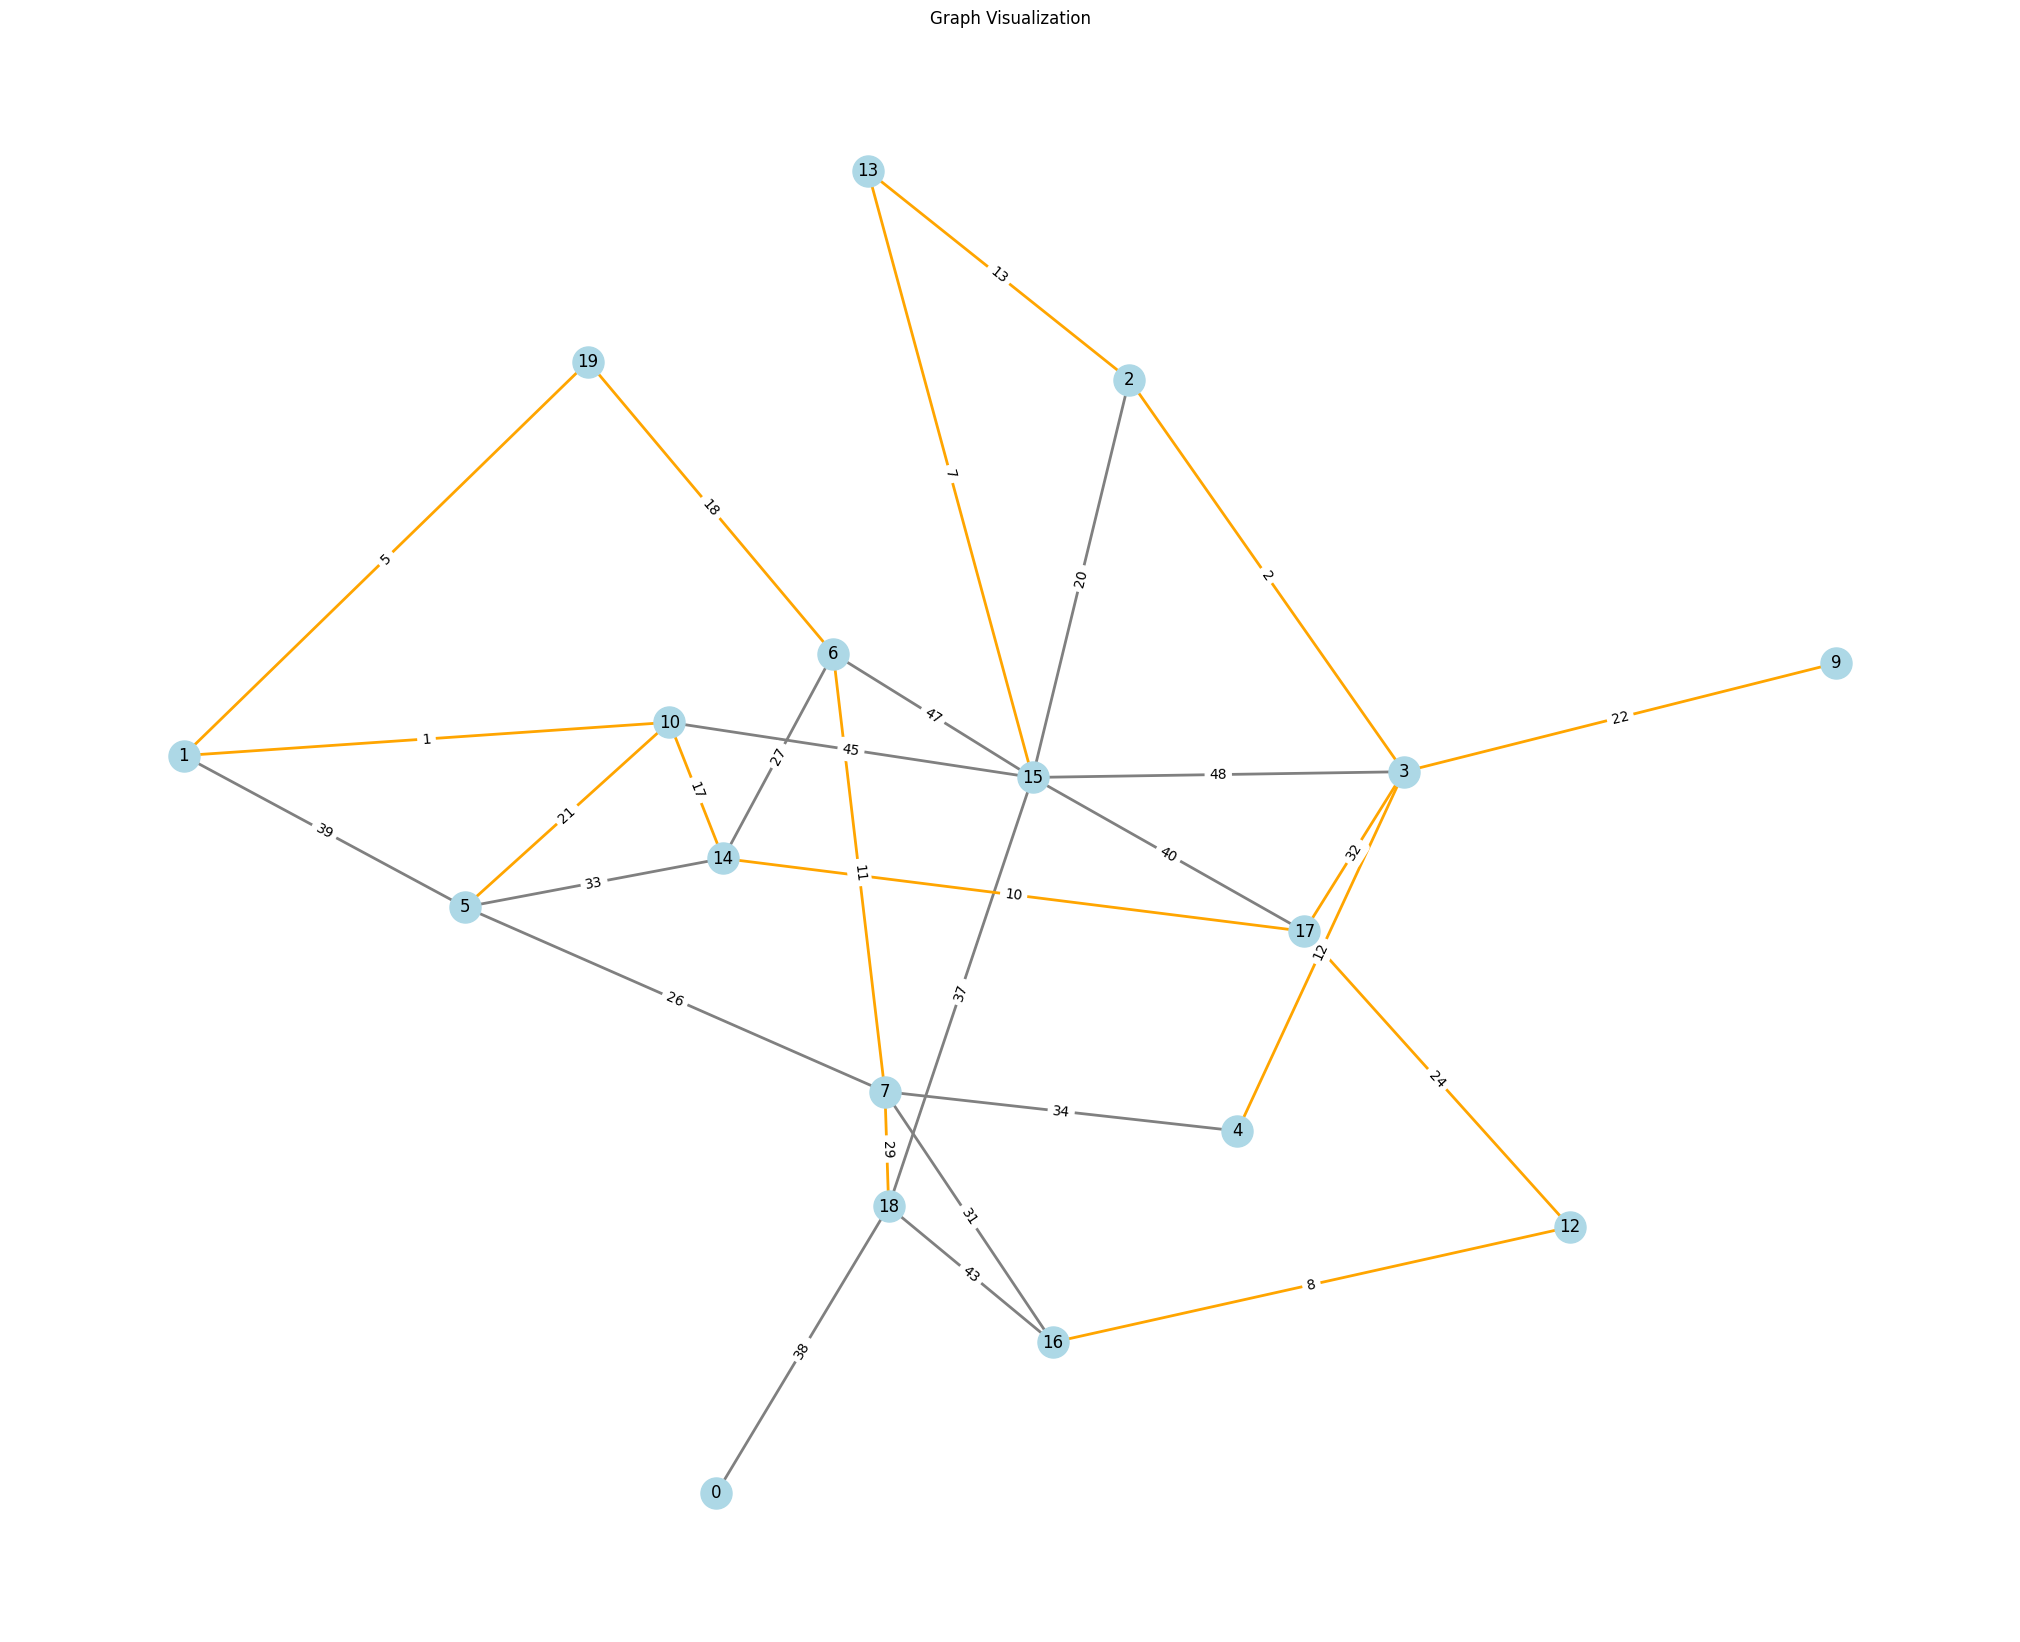

In [19]:
visualize_graph(G, network.nodes, show_mst_edges=True, seed=50)

Node 7 doesn't know its part of fragment 17 when it recieves its check message from node 4 (node 4 is trying to find their MWOE).

We need to check what node 4 knows about the fragments that are in the process of being merged.

A new fragment message must contain two things:
1. The ID of the fragment the node is joining
2. The ID of the other fragment being merged with

For any two nodes in the new fragment, it may take longer for one of the nodes to receive the new fragment message, and the time difference might be long enough for the node who receives the new fragment message earlier to then subsequently receive the FIND_MWOE message and then also send a check message to a node that should be in the new fragment but is still waiting to hear.

If the merge is good why is the new fragment not working?!

The singleton nodes are just going around in circles never merging. These nodes are 1 and 3.

Phase 2: (2,1), (5,3), (8,5)
- Fragment 2 (nodes: 1,2,4)

I'm merging a single node with two other fragments and therefore the ids are interferring. See in example above node 5 (i.e. fragment 6) is merging with both fragment 3 and fragment 8. I assume this cannot happen as multiple node will want to propagate their IDs.

Let's think about this:
- Fragment 8 shouldn't be merging as fragment 6 doesn't want to merge with it. So why is fragment 8 merging?

self.adjacent_edges[sender]["status"] = EdgeState.BRANCH

I think a node is receiving a message from a node it is not adjacent to?

Will have to look at the nodes sending the NEW_FRAGMENT messages and who the messages are sent to.

I think now node 2 is unable to find a candidate but keeps trying...

6 is waiting on response from 2 I think
1 has sent its MWOE to its parent 2 and is left sitting in the broadcast_mwoe state waiting for the mwoe of the fragment
2 can't seem to find its MWOE but doesn't know (2,3) is a rejected edge yet
3 has realised it has no MWOE and has passed this info to its parent 5 and is now waiting to hear the MWOE of the fragment
4 is in the same situation as 3
5 has found its mwoe to 8 of weight 2.4 and sent it to its parent 6 and is waiting to hear the MWOE of the fragment
6 is waiting to hear from 1 more its neighbours about the MWOE of that subtree of the fragment. The node it is waiting on is 2
Nodes 7 and 8 are both ready to merge with 8 having a merge candidate of 5.


Have a situation where a nodes old MWOE is still being used. When can I clear the MWOE of a node? Let's think when they're told to search at that point clear it right?

I think node 8 merges with node 5 and then subsequently moves into search and checks with 1 if its in a different fragment but it does this before 1 has received its new fragment update. Is it only an issue when the MOE will be in your new fragment? I assume so yes. They don't merge anyway because node 1 knows node 8 isn't in its fragment.

The ID of the other fragment involved in the merge could also be broadcasted with the new_fragment messages so that when nodes come to find their MWOE, if the CHECK messages they send to nodes which are supposed to be in their fragment (but are yet to receive the new fragment message), the node doesn't use as a MWOE.

I need nodes to wait until they've received new fragment before they search for their next MOE? Need to think about when nodes move into find moe state.

In [20]:
def extract_mst_from_module_nodes(graph, nodes):
    """

    Extract MST edges (branch edges) from nodes using statuses defined in the module.



    :param graph: NetworkX graph

    :param nodes: Dictionary of nodes with their states

    :return: Set of MST edges inferred from the module's logic

    """

    mst_edges = set()

    for node_id, node_data in nodes.items():

        # Check adjacent edges and their status

        adjacent_edges = getattr(node_data, "adjacent_edges", {})

        for neighbor_id, edge_data in adjacent_edges.items():

            if str(edge_data.get("status")) == "EdgeState.BRANCH":

                mst_edges.add(
                    (min(node_id, neighbor_id), max(node_id, neighbor_id))
                )  # Unordered edge

    return mst_edges

In [21]:
def compare_msts_with_module(graph, network):
    """

    Compare the MST inferred using the module's logic with the NetworkX MST.



    :param graph: NetworkX graph

    :param network: Network instance created using the network_module

    :return: None, prints the results of the comparison

    """

    # Extract MST edges using the module's node statuses

    inferred_mst_edges = extract_mst_from_module_nodes(graph, network.nodes)

    # Generate MST using NetworkX

    nx_mst = nx.minimum_spanning_tree(graph)

    nx_mst_edges = set(tuple(sorted(edge)) for edge in nx_mst.edges())

    # Compare and print results

    if inferred_mst_edges == nx_mst_edges:
        print(inferred_mst_edges)
        print(nx_mst_edges)

        print("The inferred MST matches the NetworkX MST.")

    else:

        print("The inferred MST does NOT match the NetworkX MST.")

        print("Inferred MST edges:", inferred_mst_edges)

        print("NetworkX MST edges:", nx_mst_edges)

        # Output the code to regenerate the graph
        print("\nCode to generate the graph:")
        print("graph = nx.Graph()")

        for edge in graph.edges(data=True):
            u, v, data = edge
            weight = data.get('weight', 1)  # Default weight is 1 if not specified
            print(f"graph.add_edge({u}, {v}, weight={weight})")

In [22]:
compare_msts_with_module(G, network)

The inferred MST does NOT match the NetworkX MST.
Inferred MST edges: {(12, 17), (3, 4), (10, 14), (3, 17), (14, 17), (12, 16), (2, 13), (2, 3), (6, 7), (5, 10), (13, 15), (3, 9), (1, 10), (6, 19), (1, 19), (7, 18)}
NetworkX MST edges: {(12, 17), (3, 4), (10, 14), (3, 17), (14, 17), (12, 16), (2, 13), (2, 3), (6, 7), (5, 10), (13, 15), (3, 9), (1, 10), (0, 18), (6, 19), (1, 19), (7, 18)}

Code to generate the graph:
graph = nx.Graph()
graph.add_edge(0, 18, weight=38)
graph.add_edge(18, 7, weight=29)
graph.add_edge(18, 15, weight=37)
graph.add_edge(18, 16, weight=43)
graph.add_edge(1, 5, weight=39)
graph.add_edge(1, 19, weight=5)
graph.add_edge(1, 10, weight=1)
graph.add_edge(5, 14, weight=33)
graph.add_edge(5, 10, weight=21)
graph.add_edge(5, 7, weight=26)
graph.add_edge(19, 6, weight=18)
graph.add_edge(10, 14, weight=17)
graph.add_edge(10, 15, weight=45)
graph.add_edge(2, 3, weight=2)
graph.add_edge(2, 13, weight=13)
graph.add_edge(2, 15, weight=20)
graph.add_edge(3, 17, weight=32)
gr

In [23]:
import matplotlib.pyplot as plt
import networkx as nx
import random


def generate_random_weighted_graph(num_nodes, num_edges, weight_range):
    """
    Generate a random weighted graph with distinct edge weights.
    """
    if num_edges > num_nodes * (num_nodes - 1) // 2:
        raise ValueError("Too many edges for the given number of nodes.")

    # Generate a random graph
    G = nx.gnm_random_graph(num_nodes, num_edges)

    # Generate distinct weights
    weights = random.sample(range(weight_range[0], weight_range[1] + 1), num_edges)

    # Assign weights to edges
    for edge, weight in zip(G.edges, weights):
        G.edges[edge]["weight"] = weight

    return G


def draw_weighted_graph(G):
    """
    Draw the graph with edge weights.
    """
    pos = nx.spring_layout(G, seed=123)  # Position nodes using the spring layout
    plt.figure(figsize=(8, 6))

    # Draw nodes and edges
    nx.draw(
        G, pos, with_labels=True, node_color="lightblue", node_size=500, font_size=10
    )

    # Draw edge labels (weights)
    edge_labels = nx.get_edge_attributes(G, "weight")
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    plt.title("Random Weighted Graph")
    plt.show()

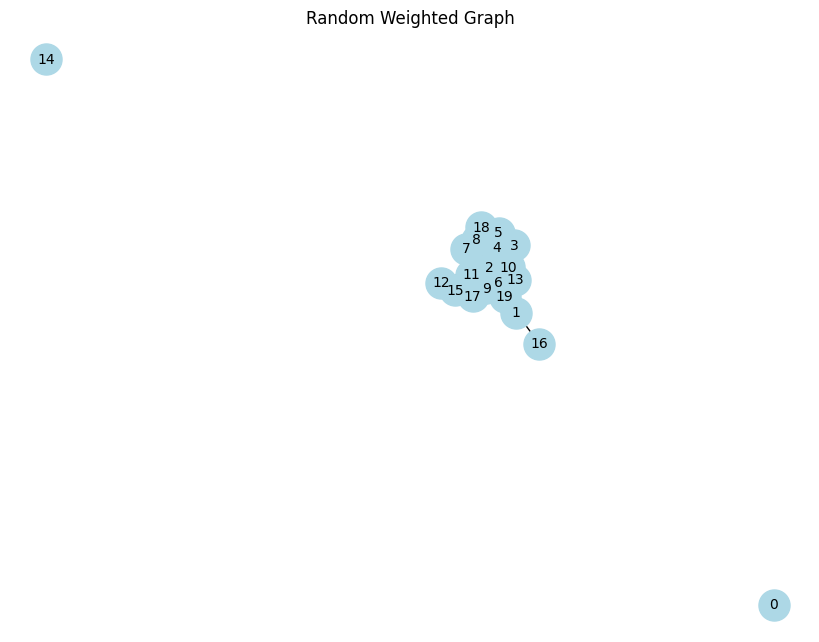

I node 0 am the leader of fragment 0 and the minimum weight outgoing edge of the fragment is inf
I node 1 am the leader of fragment 1 and the minimum weight outgoing edge of the fragment is 37
I node 2 am the leader of fragment 2 and the minimum weight outgoing edge of the fragment is 13
I node 3 am the leader of fragment 3 and the minimum weight outgoing edge of the fragment is 2
I node 4 am the leader of fragment 4 and the minimum weight outgoing edge of the fragment is 32
I node 5 am the leader of fragment 5 and the minimum weight outgoing edge of the fragment is 6
I node 6 am the leader of fragment 6 and the minimum weight outgoing edge of the fragment is 16
I node 7 am the leader of fragment 7 and the minimum weight outgoing edge of the fragment is 2
I node 8 am the leader of fragment 8 and the minimum weight outgoing edge of the fragment is 4
I node 9 am the leader of fragment 9 and the minimum weight outgoing edge of the fragment is 10
I node 10 am the leader of fragment 10 and 

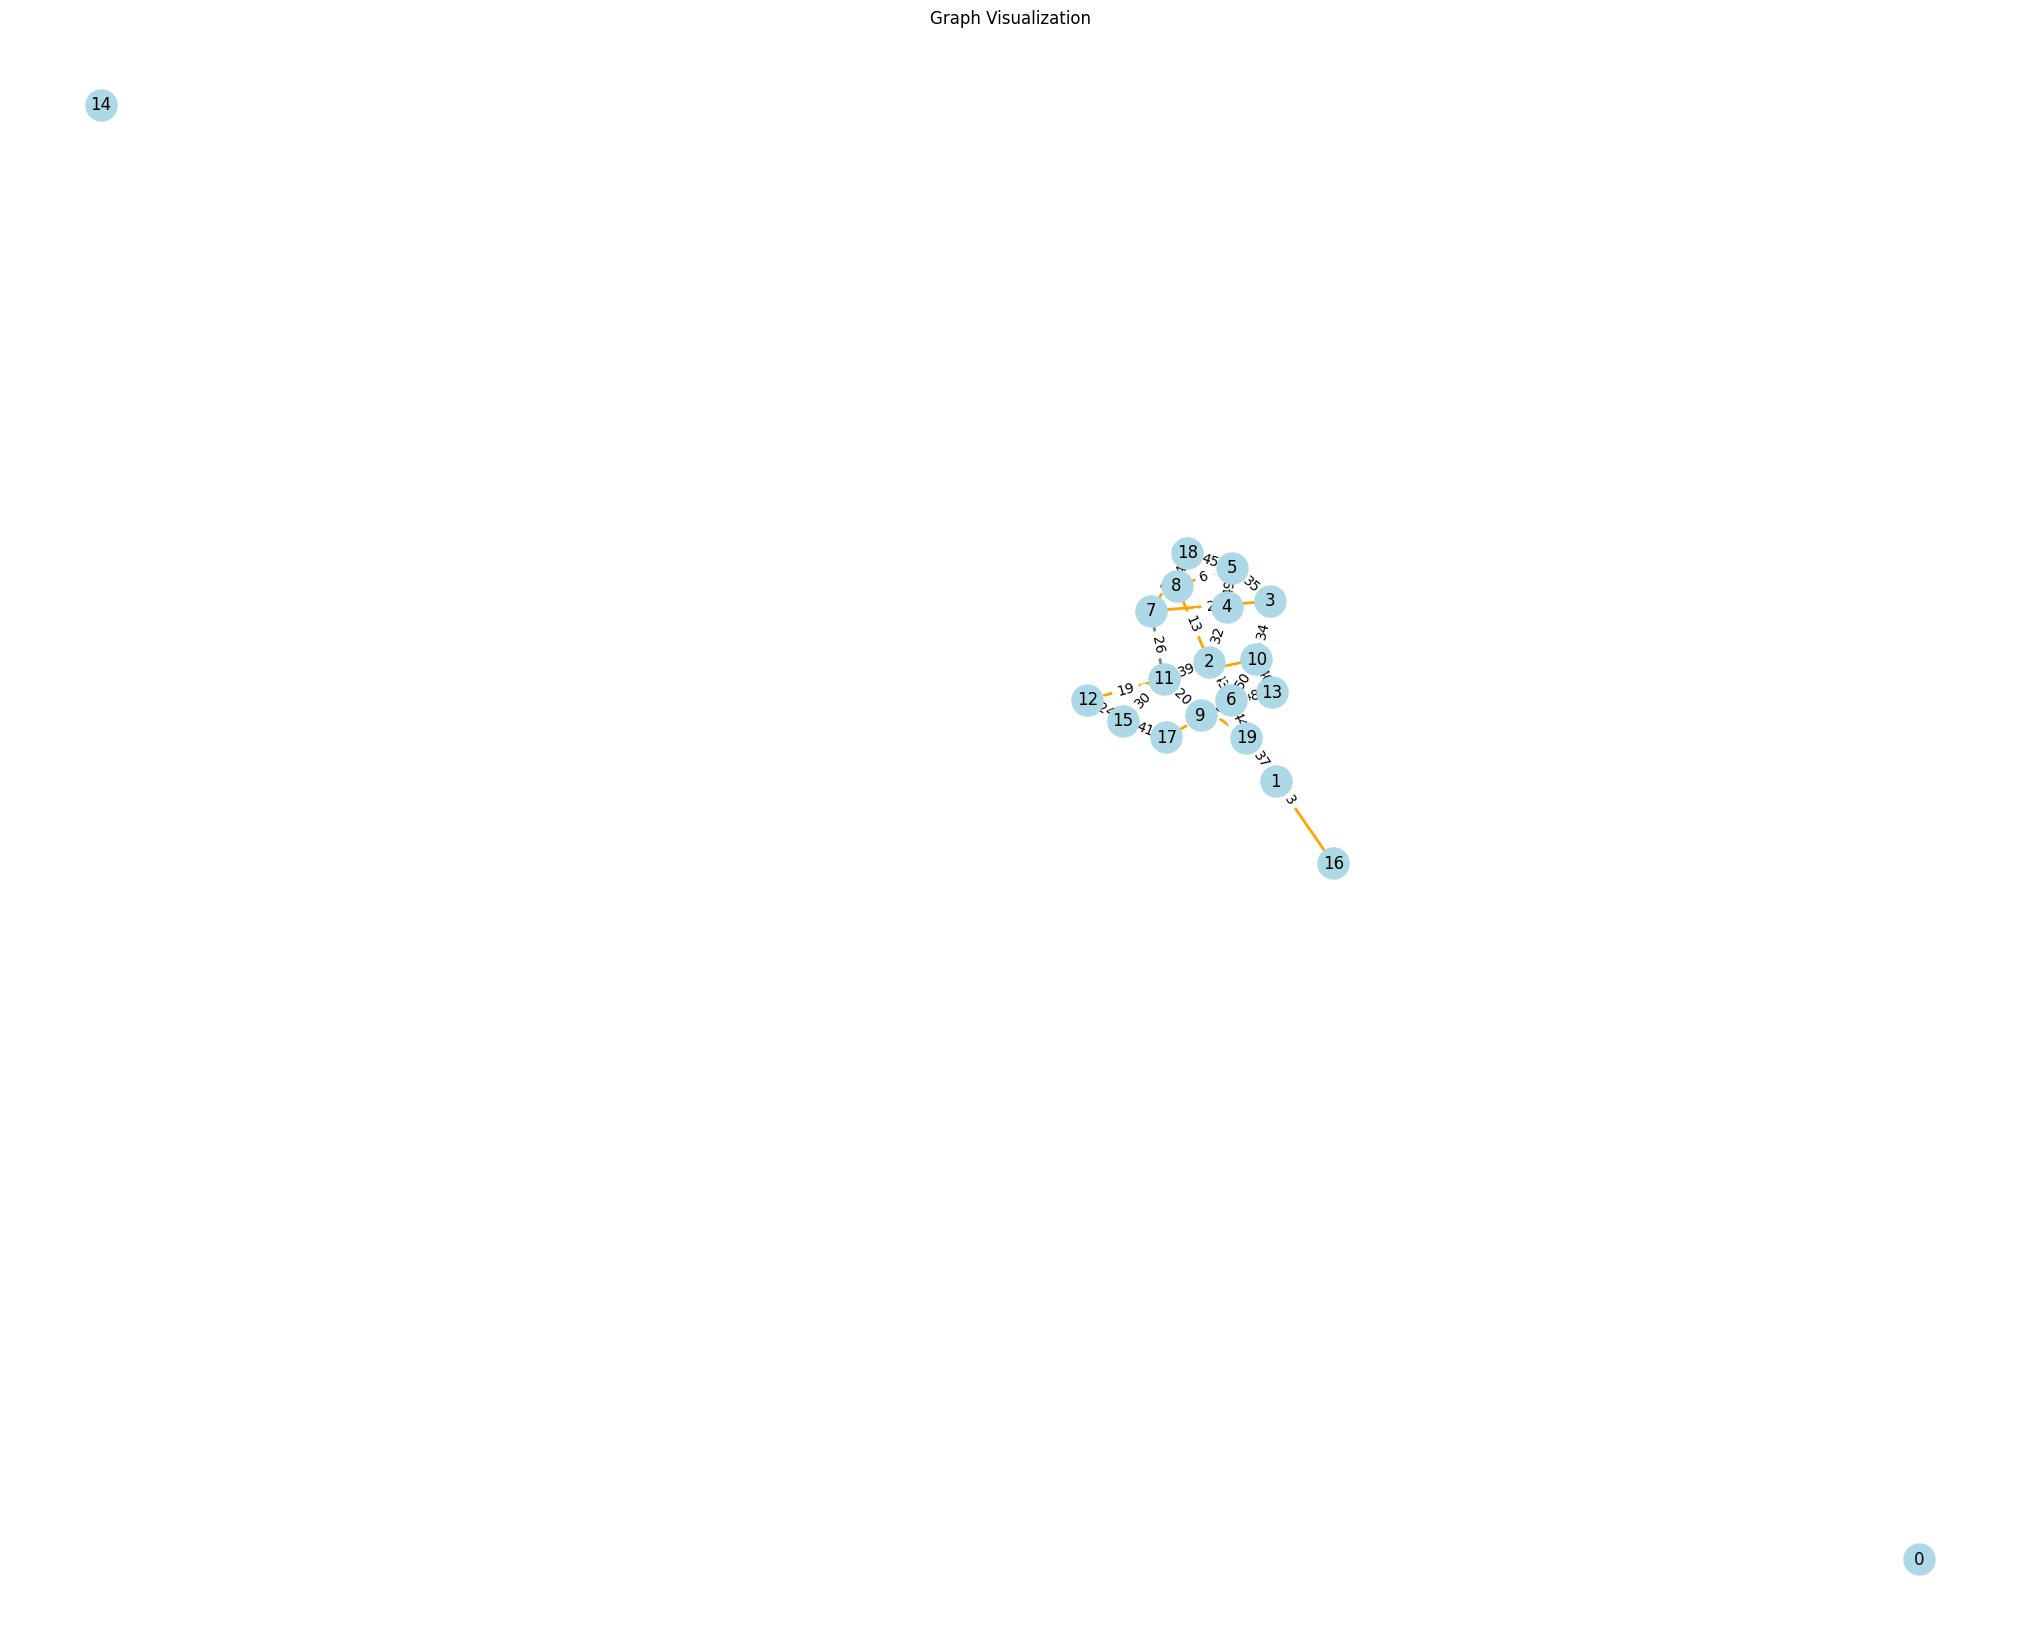

{(2, 4), (10, 11), (9, 13), (5, 8), (7, 18), (3, 7), (11, 19), (16, 19), (2, 19), (6, 17), (11, 12), (12, 15), (8, 18), (9, 11), (1, 19), (6, 9), (2, 8)}
{(2, 4), (10, 11), (9, 13), (5, 8), (7, 18), (3, 7), (11, 19), (16, 19), (2, 19), (6, 17), (11, 12), (12, 15), (8, 18), (9, 11), (1, 19), (6, 9), (2, 8)}
The inferred MST matches the NetworkX MST.


In [24]:
# Generate and draw the graph
num_nodes = 20
num_edges = 30
weight_range = (1, 50)

random_weighted_graph = generate_random_weighted_graph(
    num_nodes, num_edges, weight_range
)
draw_weighted_graph(random_weighted_graph)

random_network = WeightedNetwork(random_weighted_graph, GHSNode)
random_network.run(500)
visualize_graph(
    random_weighted_graph, random_network.nodes, show_mst_edges=True, seed=123
)
compare_msts_with_module(random_weighted_graph, random_network)